In [10]:
import glob
import seaborn as sns
import pandas as pd
import matplotlib.image as img
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from keras.utils import to_categorical
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
import keras
from keras.models import Sequential
from sklearn.metrics import accuracy_score
from keras.layers import Dense, Activation, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.layers import BatchNormalization
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential



In [21]:
# Parámetros iniciales
image_size = (150, 150) 
batch_size = 350  
train_dir = '/kaggle/input/animalsvsplants/train'
test_dir = '/kaggle/input/animalsvsplants/test'


Cargamos las imagenes y Verificamos que esten cargadas cadauna de las clases

Found 5406 files belonging to 16 classes.
Using 4325 files for training.
Found 5406 files belonging to 16 classes.
Using 1081 files for validation.
Clases encontradas: ['Black-grass', 'Charlock', 'Cleavers', 'Common Chickweed', 'Common wheat', 'Fat Hen', 'Loose Silky-bent', 'Maize', 'Scentless Mayweed', 'Shepherds Purse', 'Small-flowered Cranesbill', 'Sugar beet', 'cat', 'cow', 'dog', 'horse']


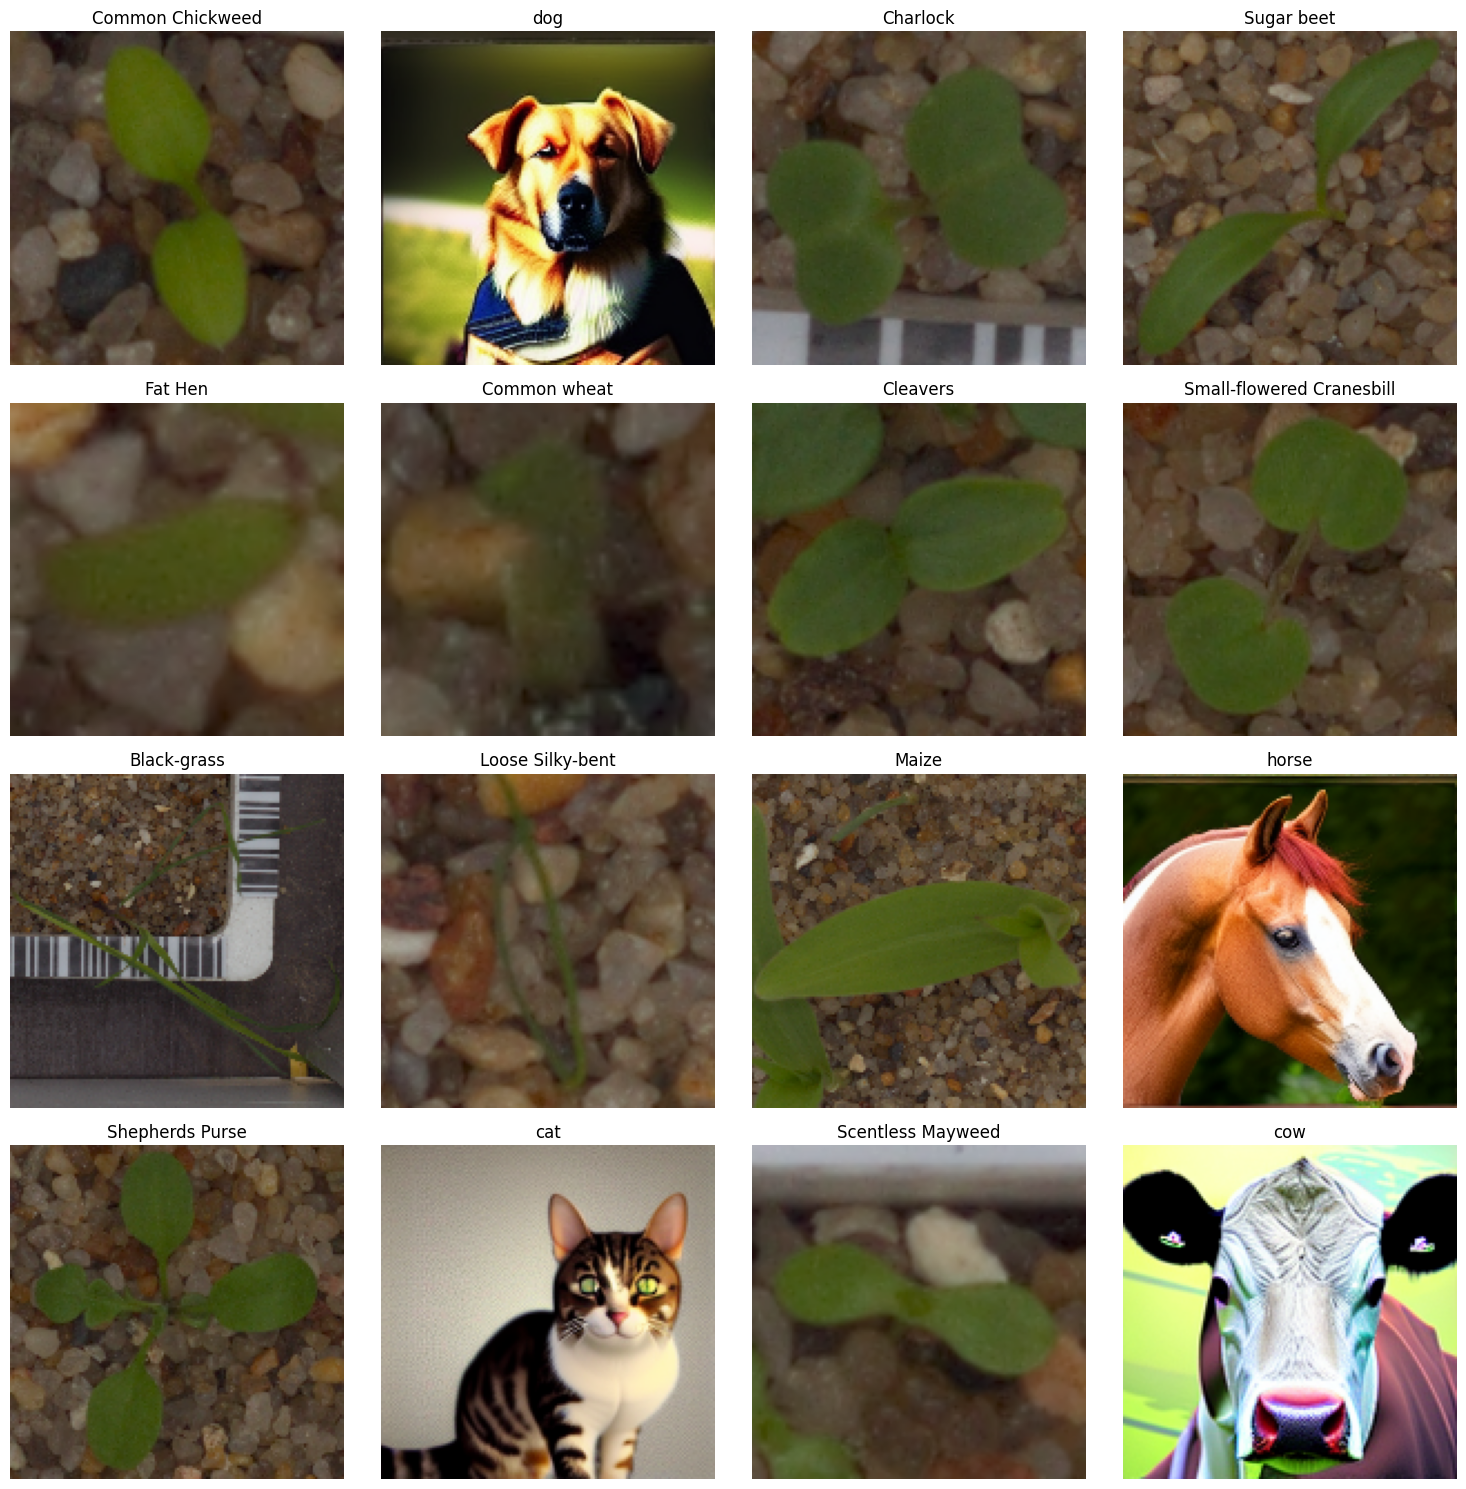

In [12]:

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=image_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=image_size,
    batch_size=batch_size
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Clases encontradas: {class_names}")

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

plt.figure(figsize=(15, 15))
selected_classes = set()
shown_images = {}

for images, labels in train_ds:
    for i in range(len(labels)):
        label = labels[i].numpy()
        class_name = class_names[label]

        if class_name not in selected_classes:
            selected_classes.add(class_name)
            shown_images[class_name] = images[i].numpy().astype("uint8")
        if len(selected_classes) == num_classes:
            break

    if len(selected_classes) == num_classes:
        break
for idx, (label, image) in enumerate(shown_images.items()):
    ax = plt.subplot(4, 4, idx + 1)
    plt.imshow(image)
    plt.title(label)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
model = Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(image_size[0], image_size[1], 3)),  # Normalización de las imágenes
 
    Conv2D(16, (2, 2), padding='same', activation='relu'),
    MaxPooling2D(),

    Conv2D(32, (2, 2), padding='same', activation='relu'),
    MaxPooling2D(),
    Dropout(0.1),

    Conv2D(64, (2, 2), padding='same', activation='relu'),
    MaxPooling2D(),

    Conv2D(128, (2, 2), padding='same', activation='relu'),
    MaxPooling2D(),
    Dropout(0.1),

    Flatten(),
    Dense(128, activation='relu'), 
    Dropout(0.2), 
    Dense(50, activation='relu'),
    Dropout(0.2),
    Dense(16)
])

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 150, 150, 16)   │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 75, 75, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 75, 75, 32)     │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 37, 37, 64)     │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 18, 18, 128)    │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 10368)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     1,327,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 50)             │         6,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           816 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,377,938 (5.26 MB)

 Trainable params: 1,377,938 (5.26 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
from tensorflow.keras.callbacks import EarlyStopping
epochs = 40
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=[early_stopping]
)

Epoch 1/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 49s 4s/step - accuracy: 0.0968 - loss: 2.7492 - val_accuracy: 0.1221 - val_loss: 2.6953
Epoch 2/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 78s 3s/step - accuracy: 0.1220 - loss: 2.6583 - val_accuracy: 0.1600 - val_loss: 2.4861
Epoch 3/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 43s 3s/step - accuracy: 0.1657 - loss: 2.4887 - val_accuracy: 0.2128 - val_loss: 2.3222
Epoch 4/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 43s 3s/step - accuracy: 0.2233 - loss: 2.3159 - val_accuracy: 0.2923 - val_loss: 2.0758
Epoch 5/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 43s 3s/step - accuracy: 0.3063 - loss: 2.0907 - val_accuracy: 0.3867 - val_loss: 1.8051
Epoch 6/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.3633 - loss: 1.8782 - val_accuracy: 0.4450 - val_loss: 1.6387
Epoch 7/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 43s 3s/step - accuracy: 0.3910 - loss: 1.7609 - val_accuracy: 0.4820 - val_loss: 1.5231
Epoch 8/40
13/13 ━━━━━━━━━━━━━━━━━━━━ 44s 3s/step - accuracy: 0.4520 - loss: 1.6187 - val_accuracy: 0.5051 - val_loss:

In [23]:
import os
desire_size = (150, 150)  
x_obb_c = []
file_ob = []

for file in glob.glob(os.path.join(test_dir, "*")):
    im = Image.open(file)
    imf_resis = im.resize(desire_size)
    x_obb_c.append(np.array(imf_resis))
    file_ob.append(os.path.basename(file))  

y_hat = []
for f in file_ob:
    img_path = os.path.join(test_dir, f)
    if not os.path.isfile(img_path):
        print(f"Archivo no encontrado: {img_path}")
        continue

    img = tf.keras.utils.load_img(img_path, target_size=desire_size)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)
    
    predicciones = model.predict(img_array)
    score = tf.nn.softmax(predicciones[0])
    y_hat.append(score.numpy())

print("Predicciones realizadas correctamente.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━

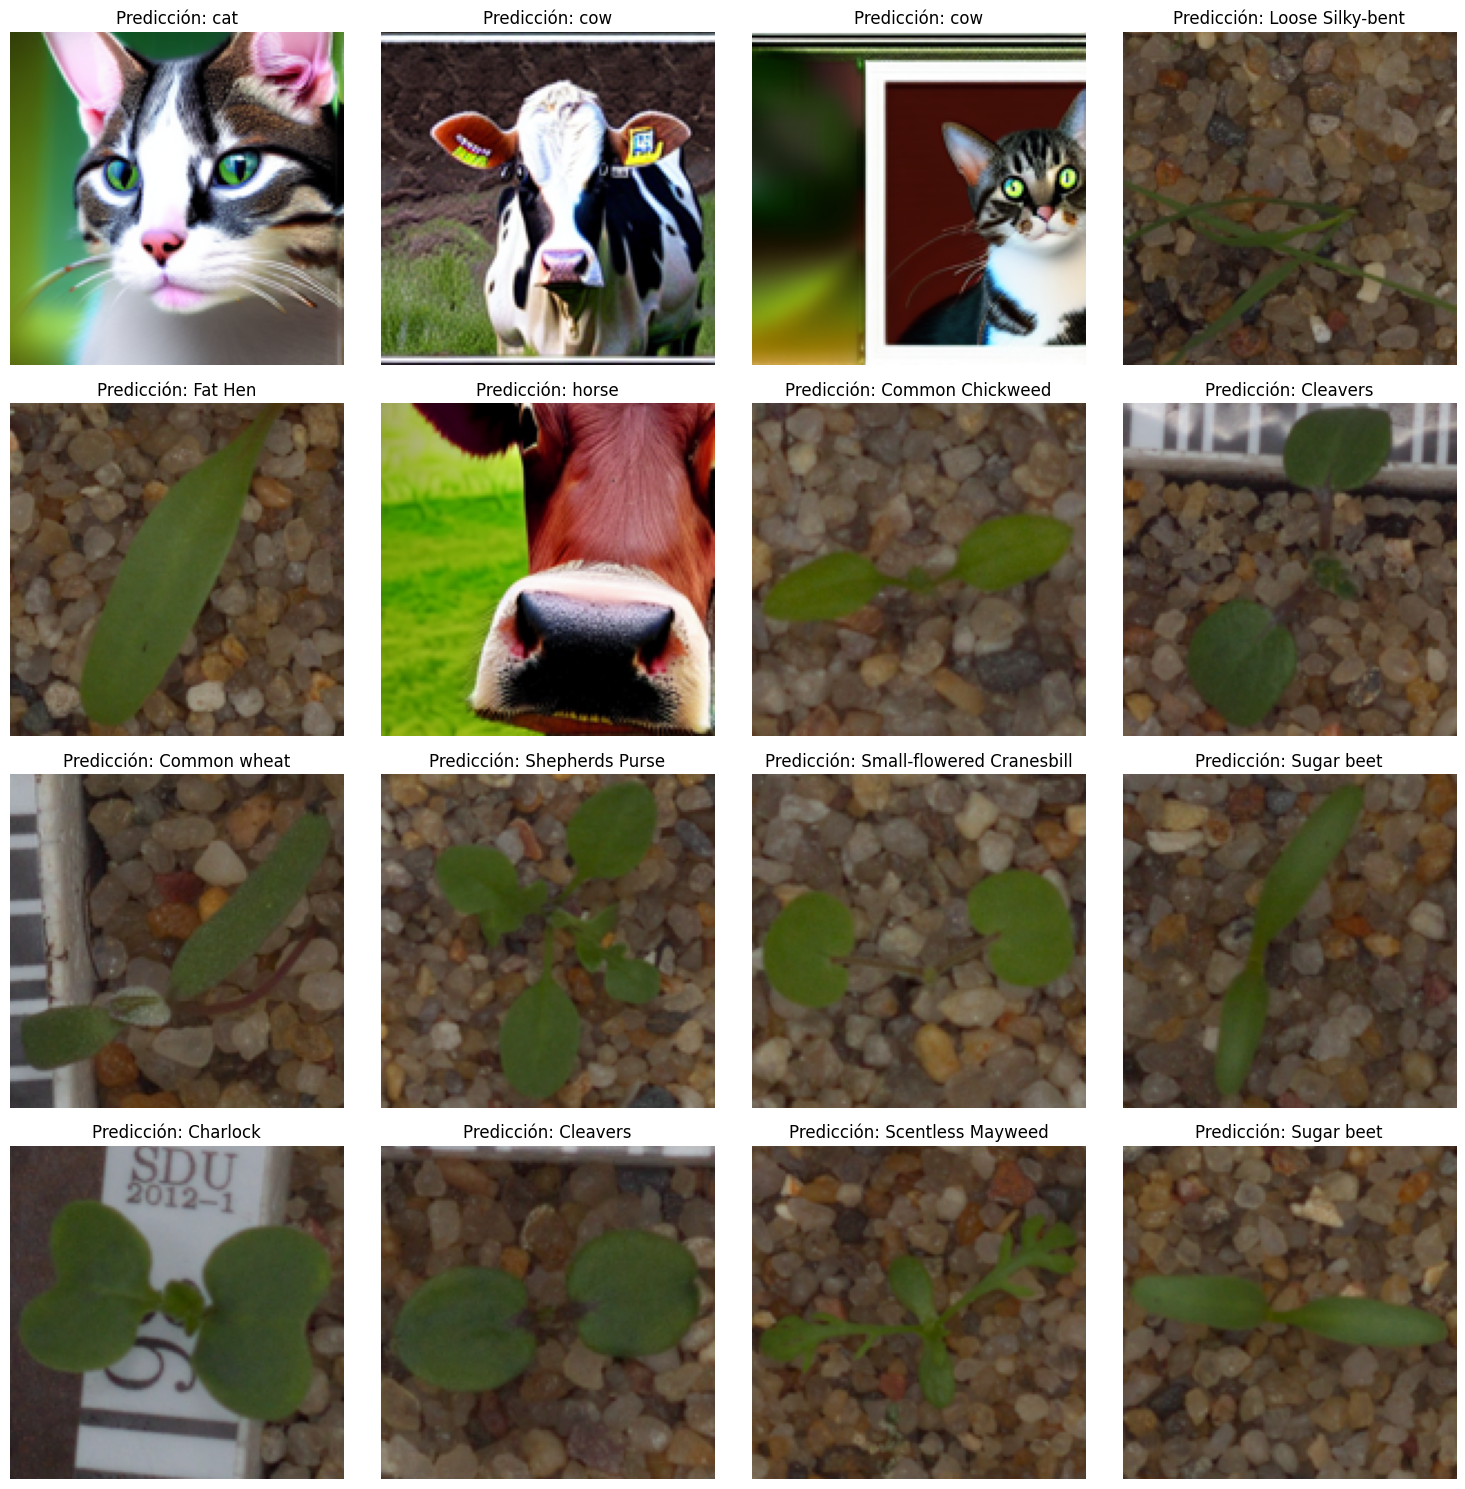

In [30]:
plt.figure(figsize=(15, 15))
for i in range(16): 
    if i >= len(x_obb_c):  
        break
    img = x_obb_c[i]  
    predicted_label = class_names[np.argmax(y_hat[i])] 

    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(img.astype("uint8"))
    plt.title(f"Predicción: {predicted_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [31]:
for i, score in enumerate(y_hat[:16]):
    predicted_label = class_names[np.argmax(score)]
    confidence = 100 * np.max(score)
    print(f"Imagen {i + 1}: Predicción = {predicted_label}, Confianza = {confidence:.2f}%")

Imagen 1: Predicción = cat, Confianza = 98.19%
Imagen 2: Predicción = cow, Confianza = 99.49%
Imagen 3: Predicción = cow, Confianza = 91.70%
Imagen 4: Predicción = Loose Silky-bent, Confianza = 63.39%
Imagen 5: Predicción = Fat Hen, Confianza = 78.12%
Imagen 6: Predicción = horse, Confianza = 35.61%
Imagen 7: Predicción = Common Chickweed, Confianza = 92.06%
Imagen 8: Predicción = Cleavers, Confianza = 57.75%
Imagen 9: Predicción = Common wheat, Confianza = 43.16%
Imagen 10: Predicción = Shepherds Purse, Confianza = 63.01%
Imagen 11: Predicción = Small-flowered Cranesbill, Confianza = 99.71%
Imagen 12: Predicción = Sugar beet, Confianza = 52.77%
Imagen 13: Predicción = Charlock, Confianza = 99.96%
Imagen 14: Predicción = Cleavers, Confianza = 98.54%
Imagen 15: Predicción = Scentless Mayweed, Confianza = 54.68%
Imagen 16: Predicción = Sugar beet, Confianza = 96.86%


In [34]:

submission_df = pd.DataFrame({
    'filename': file_ob,  
    'label': [class_names[np.argmax(prediction)] for prediction in y_hat]  
})

submission_df.to_csv('submission.csv', index=False)
print("Archivo de envío generado: submission.csv")

Archivo de envío generado: submission.csv


11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


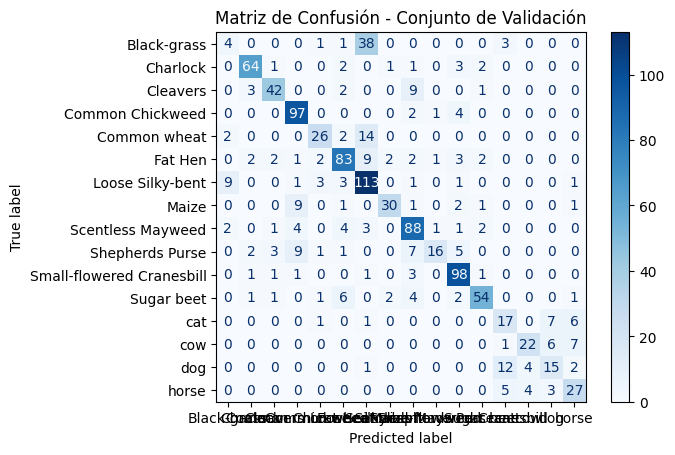

In [33]:

y_true = []  
y_pred = []  

for images, labels in val_ds:
    predictions = model.predict(images)
    predicted_classes = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)


cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión - Conjunto de Validación")
plt.show()